# Plots and preprocessing 

## data loading

In [1]:
###  import package!!!
import time
import numpy as np
from sklearn import cluster, covariance
import matplotlib
import matplotlib as  mpl
import matplotlib.pyplot as plt

import os
import scipy
from scipy import interpolate


import matplotlib.cm as cm
import scipy.stats as stats

import pandas as pd

import scipy.io as sio

import seaborn as sns 

large = 18; med = 18; small = 16
params = {'axes.titlesize': large,
          'legend.fontsize': med,
          'figure.figsize': (10, 8),
          'axes.labelsize': med,
          'axes.titlesize': med,
          'xtick.labelsize': med,
          'ytick.labelsize': med,
          'figure.titlesize': large}
plt.rcParams.update(params)
# plt.style.use('seaborn-whitegrid')
# sns.set_style("white") ####can changed!!

In [2]:
#data from goodtraces.txt 
# change the path according to you own location  
file_path = r'../data/Clustering/CuP+CAF-1_2(0.2mM).txt'
data = np.loadtxt(file_path)

data.shape

(1852500, 2)

In [3]:
data = data[: 10000000]
mdata, ndata = data.shape

## 1d & 2d histograms

In [4]:
#plot 1d and 2d histograms;

def concate_to_one_row(dataCut):
    tempData = np.vstack([x for x in dataCut])
    
    dataDist = tempData[:, 0]
    dataCondu = tempData[:, 1]

    return dataDist, dataCondu


def plothistofClusters(label_junc_or_not, dataCut):
    labelsmax = len(set(label_junc_or_not))
    j=0
    for i in set(label_junc_or_not):
        plt.figure(labelsmax, figsize=(7, 5*labelsmax), facecolor='#C0C0C0')

        index_i = np.array(np.where(label_junc_or_not == i)).reshape(-1)

        if index_i.shape[0] < 3:
            continue
        
        ClusterI_Cut = dataCut[index_i]
        
        ClusterI_x, ClusterI = concate_to_one_row(ClusterI_Cut)
        

        plt.subplot(labelsmax, 1, j+1)
        j += 1
#         plt.title('ClusterData %s %s' %(i, index_i.shape[0]))
        ClusterI_2dHist = plt.hist(ClusterI, bins = 300, range=(-7, 1),
                                   histtype = 'stepfilled', alpha = 0.8, 
            label='Cluster%d, %.5s%%' %(i, index_i.shape[0]*100/label_junc_or_not.shape[0]), 
                                   density=True, facecolor='#00BFFF')
                                  
        plt.legend(fontsize=22, loc='upper center')
#         plt.title('Histogram')
        plt.ylabel('Counts')
        plt.xlabel('$log(G/G_0)$')
        plt.xlim([-7, 1])
        plt.xticks([i for i in range(-7, 2)])
        plt.grid()

def plot2dCloudofClusters(Label_junc, dataCut):    
    labelsmax = len(set(Label_junc)) 
    j = 0
#     print(labelsmax)
    for i in set(Label_junc):
        plt.figure(labelsmax, figsize=(4*labelsmax, 5), facecolor='#C0C0C0')

        index_i, = np.array(np.where(Label_junc == i))
    #     print(i)
        if index_i.shape[0] < 3:
            continue

        ClusterI_Cut = dataCut[index_i]
        ClusterI_x, ClusterI = concate_to_one_row(ClusterI_Cut)

        plt.subplot(1, labelsmax, j+1)
        j += 1
        plt.title('ClusterData %d %s' %(i, index_i.shape[0]))
        plt.xlabel('Distance /nm')
        if j==1:
            plt.ylabel('Conductance /log(G/G0)')
        ClusterI_2dHist = plt.hist2d(ClusterI_x.reshape(-1), 
                                       ClusterI.reshape(-1), 100, range=((-0.5, 3)),
                             cmap=cm.hot, normed = True,vmax=0.3, vmin=0.00)
        
    return labelsmax


def plot_hist2(labels1Cluster, dataCut):
    plt.figure(figsize=(12, 8))
    for i in set(labels1Cluster):
        index_i = np.array(np.where(labels1Cluster == i)).reshape(-1)

        ClusterI_Cut = dataCut[index_i]
        ClusterI_x, ClusterI = concate_to_one_row(ClusterI_Cut)

       
        plt.title('Cluster%s #%s' %(i, index_i.shape[0]))
        ClusterI_2dHist = plt.hist(ClusterI.reshape(-1), bins = 730, range=(-7.5, 0.5),
                                   histtype = 'stepfilled', alpha = 0.6, 
                                   label='Cluster:%d'%(i))

        plt.title('Histogram')
        plt.ylabel('counts')
        plt.xlabel('$log(G/G_0)$')
    return ClusterI_2dHist



def plot2dCloudofClusters_2(Label_junc, dataCut, rangeH=((-0.5, 2), (-7, 1)), vmax=0.5, save=False):    
    labelsmax = len(set(Label_junc)) 
    j = 0
#     print(labelsmax)
#     cmap = plt.cm.get_cmap("jet_r")
#     cmap.set_under("white")
#     my_map = cm.get_cmap('hsv', 200)#YlGn # PuBu #OrRd #Greys
#     newcolors = my_map(np.linspace(0, 1, 200))
#     white = np.array([200/200, 200/200, 200/200, 1])
    #newcolors[190:200, :] = green
    #newcolors[198:200,:]= white
#     newcolors[0:10,:]= white
#     newcmp = mpl.colors.ListedColormap(newcolors)
#     cm.register_cmap(name='new_bar', cmap=newcmp)
    
    plt.figure(labelsmax, figsize=(4*labelsmax, 5), facecolor='white')
    for i in set(Label_junc):
        

        index_i, = np.array(np.where(Label_junc == i))
    #     print(i)
        if index_i.shape[0] < 3:
            continue

        ClusterI_Cut = dataCut[index_i]
        ClusterI_x, ClusterI = concate_to_one_row(ClusterI_Cut)

        plt.subplot(1, labelsmax, j+1)
        j += 1
        plt.title('Cluster%d, %.5s%%' %(i, index_i.shape[0]*100/Label_junc.shape[0]))
        plt.xlabel('$\Delta z /nm$')
        if j==1:
            plt.ylabel('$\mathrm{\log(G/G_0)}$')
        ClusterI_2dHist = plt.hist2d(ClusterI_x.reshape(-1), 
                                       ClusterI.reshape(-1), (100, 300), range=rangeH,
                             cmap='bwr', density = True,vmax=vmax*.6, vmin=0.00)
#         plt.colorbar()
    if(save):
        plt.savefig(filename_data[:-4]+'LLC_Fig', dpi=600, format='tif')
    return labelsmax

In [5]:
# save the clusters you want for further processing
def saveTrace(label_junc_or_not, dataCut):
    labelsmax = len(set(label_junc_or_not))
    j=0
    for i in set(label_junc_or_not):

        index_i = np.array(np.where(label_junc_or_not == i)).reshape(-1)
        
        ClusterI_Cut = dataCut[index_i]
        
        ClusterI = np.vstack((x for x in ClusterI_Cut))
        
        np.savetxt(filename_data[:-4] + 'LLC_Cluster%d_%d_%d.txt'
                   %(len(index_i),labelsmax, i), ClusterI, fmt="%0.3f")
        del ClusterI

## original trace spliting and visualization

In [6]:
### count trace and cut individual trace
### count trace ,,split the goodtrace into single trace ---list DataDistandCondu,
### according the distance gap to split traces 

distanceGap = 0.2
Numtrace = 0
DistDiff = np.diff(data[:, 0][:])
TraceIndex = np.where(np.abs(DistDiff) > distanceGap)[0] + 1 
Numtrace = TraceIndex.shape[0] + 1
TraceIndex = TraceIndex.tolist()
TraceIndex.append(mdata)


data[TraceIndex[0]:TraceIndex[1]]

DataDistandCondu = []
DataDistandCondu.append(data[:TraceIndex[0], :])
for i in range(Numtrace-1):
    DataDistandCondu.append(data[TraceIndex[i]:TraceIndex[i+1], :])

print(len(DataDistandCondu))

741


In [7]:
dataCutFirst4000Curves = np.array(DataDistandCondu)##

In [8]:
def plotCurves(dataCutFirst4000Curves, indexArray):####for short curves,[-0.3, 1.5], [-8, 2]
    plt.figure(figsize=(10, 8))
    for index in indexArray:
        plt.plot(dataCutFirst4000Curves[index][:, 0], dataCutFirst4000Curves[index][:, 1])
    plt.yticks(np.arange(-8,2), fontsize=14)
    plt.xticks(np.arange(-0.3, 3.0+0.2, 0.2), fontsize=14)
    
    plt.xlim(-0.3, 3.0)
    plt.ylim(-8, 2)
    plt.xlabel('distance /nm', fontsize=16)
    plt.ylabel('Conductance /log(G/G0)', fontsize=16)
#     plt.xticks(np.arange())

In [9]:
# optional!
#single trace visualization: see if the traces are good traces ...

def plotCurve(datacut):
    
    plt.figure(figsize=(10, 8))
    t_start1 = time.clock()
    # list_pab = list(map(getCurve, [i for i in range(dataCondu1Cluster_SP.shape[0])]))
    for i in range(datacut.shape[0]):
        indexbetween = np.where((datacut[i][:, 1] < 0.3) & (datacut[i][:, 1] > -6.9))
        startIndex = indexbetween[0][0]
        endIndex = indexbetween[0][-1]
        plt.plot(datacut[i][startIndex:endIndex, 0], datacut[i][startIndex:endIndex, 1])

    plt.xlabel('distance /nm')
    plt.ylabel('Conductance /log(G/G0)')
    t_end1 = time.clock() - t_start1

    print('******************************')
    print("* Plot Time " + str(round(t_end1, 6)) + " second！*" )
    print('******************************')

In [10]:
# optional!
def plot(dataCutFirst4000Curves, index):
    plt.figure(figsize=(10, 8), facecolor='white')
    for e in index:
        plt.plot(dataCutFirst4000Curves[e][:, 0], dataCutFirst4000Curves[e][:, 1])
    plt.yticks(np.arange(-10,2))
    plt.ylabel('$logG/G_0$')
    plt.xlabel('$\Delta z\ (nm)$')

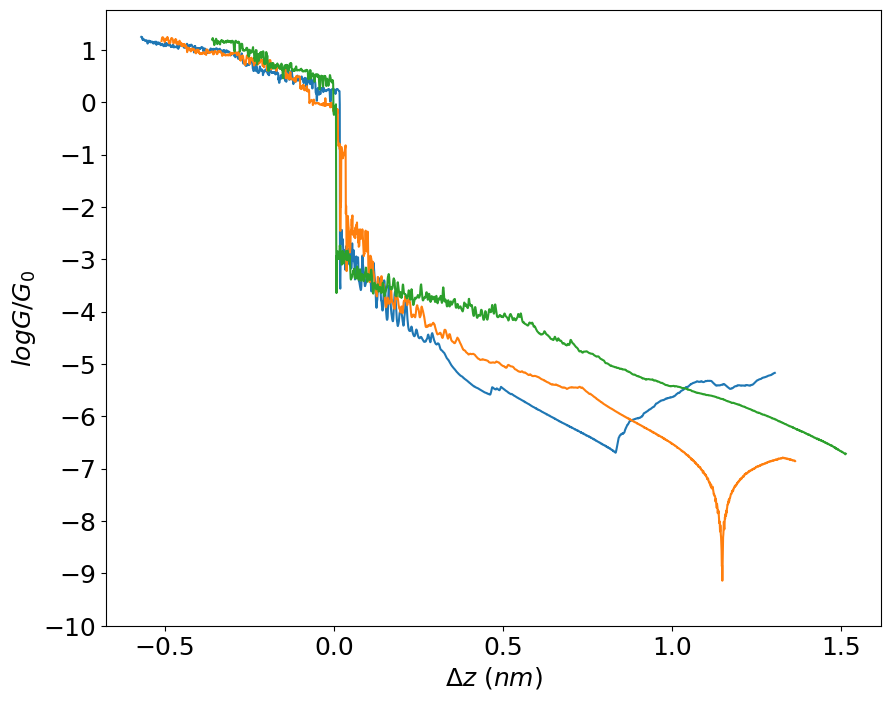

In [11]:
plot(dataCutFirst4000Curves, list(np.random.choice(np.arange(300), 3)))  # select 3 trace randomly

#  Spectrum Clustering

## implemention of the Spectrum clustering

In [12]:
# 1d histogram features
cbins = 300  
NumTraces = len(dataCutFirst4000Curves)
dataHistAll = np.ndarray((NumTraces, cbins)).astype(np.float32)###save the all traces' histogram....

for i in range(NumTraces):
    data_hist_i = np.histogram(dataCutFirst4000Curves[i][:,1], cbins, range=(-8.0, 0.3)) ###(-7.1,0.3)(-6.9, 2)) same?
    dataHistAll[i, :] = data_hist_i[0]
dataHistAll_x = data_hist_i[1][1:]

/tmp/ipykernel_2621140/932675747.py:4: RuntimeWarning: overflow encountered in cast
  dataHistAll = np.ndarray((NumTraces, cbins)).astype(np.float32)###save the all traces' histogram....
/tmp/ipykernel_2621140/932675747.py:4: RuntimeWarning: invalid value encountered in cast
  dataHistAll = np.ndarray((NumTraces, cbins)).astype(np.float32)###save the all traces' histogram....


In [13]:
# Spectrum clustering algorithm
def clusteringBtweenSP(lowlogG, highlogG, nCluster = 3, dataHistAll = dataHistAll):

    cbins = np.where((dataHistAll_x >= lowlogG) & (dataHistAll_x <= highlogG))[0]
    
    dataHistAll_6 = dataHistAll[:, cbins]
        
    histcorrcoef =  np.corrcoef(dataHistAll_6)
    histcorrcoef[np.isnan(histcorrcoef)] = 0             ####need warning???
    histcorrcoefNorm_6 = histcorrcoef * 0.5 + 0.5
    labelsList_6 = []
    
    for nCl in range(2, nCluster+1):
        SpectralFun = cluster.SpectralClustering(n_clusters=nCl, random_state=429, 
                                                 n_jobs=-1, affinity='precomputed')
        SpectralFun.fit(histcorrcoefNorm_6)  ###choose 4000 curve 
        labels = SpectralFun.labels_
        labelsList_6.append(labels)
        plt.figure(nCl)
        y1, = plt.plot(dataHistAll_x, dataHistAll.mean(axis=0), 'b', label='Original Data')
        plt.ylabel('Counts per trace')
        plt.xlabel('Conductance /$\mathrm{log(G/G_0)}')
        plt.title('%0.1f Original data and Cluster %0.1f'%(lowlogG, highlogG) )

        for i in range(nCl):
            nClusterI = (labels == i).sum()
            index_i = np.array(np.where(labels == i)).reshape(-1)
            Cluster_i_hist = dataHistAll[index_i]
            y2, = plt.plot(dataHistAll_x, Cluster_i_hist.mean(axis=0), label='Cluster %d_%d/%d ' %(i+1,nClusterI,nCl))
        plt.legend(bbox_to_anchor = (1.3, 0.5), ncol = 1, loc = 7, borderaxespad=0)
        plt.show()
    return labelsList_6, dataHistAll_6

1

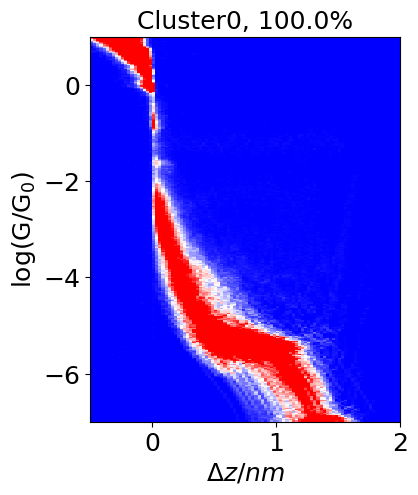

In [14]:
# visualize the 2D cloud of the source data (all traces)
ZerosAll = np.zeros((len(dataCutFirst4000Curves)))
plot2dCloudofClusters_2(ZerosAll, dataCutFirst4000Curves, 
                        rangeH=((-0.5, 2), (-7, 1)), vmax = 0.5)

/usr/local/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f68953cc180>
Traceback (most recent call last):
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", lin

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f68953cc180>
Traceback (most recent call last):
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 's

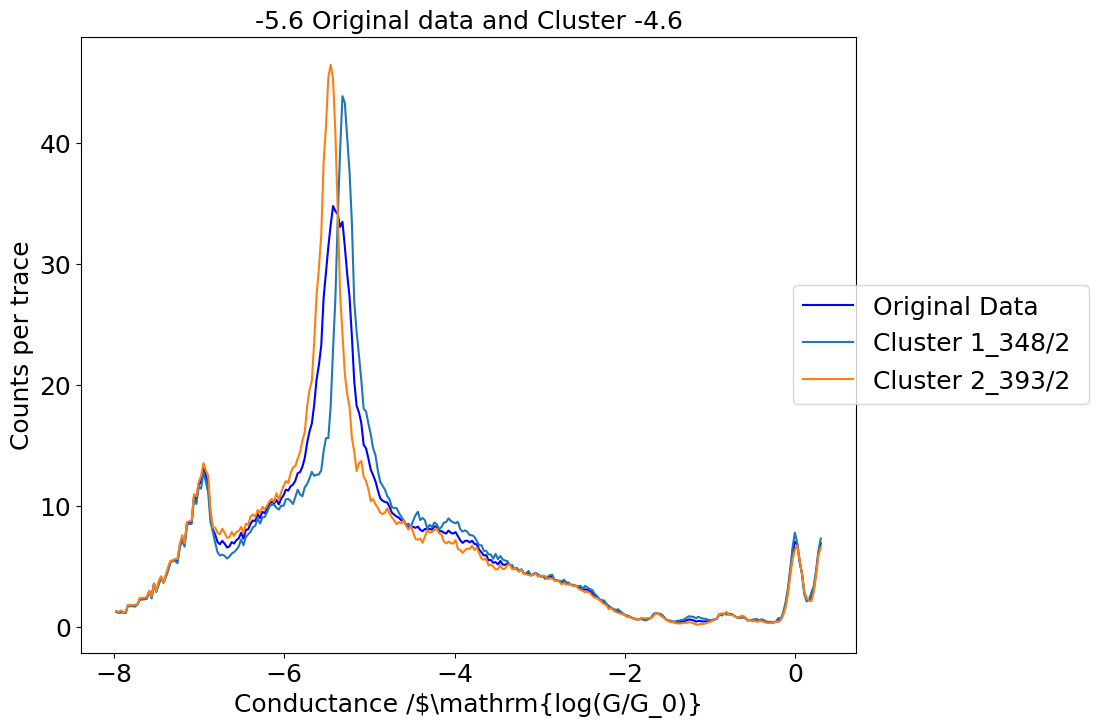

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f68942cbe20>
Traceback (most recent call last):
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 's

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f68942cbe20>
Traceback (most recent call last):
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 's

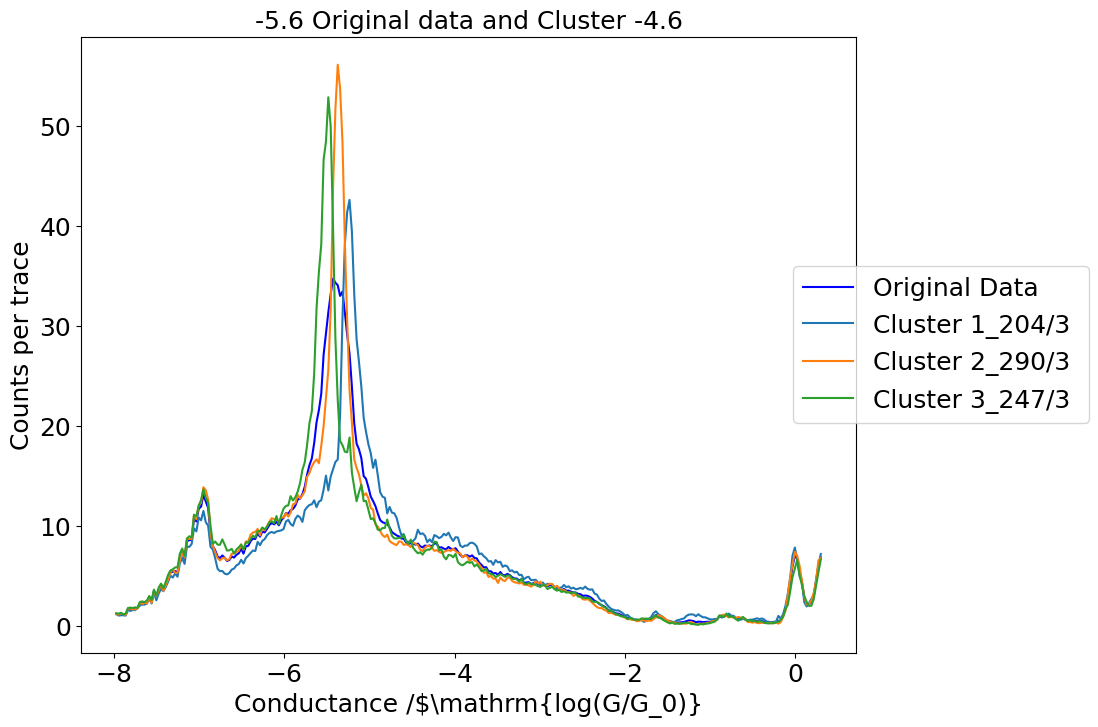

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f68942d8680>
Traceback (most recent call last):
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 's

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f68942db600>
Traceback (most recent call last):
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 's

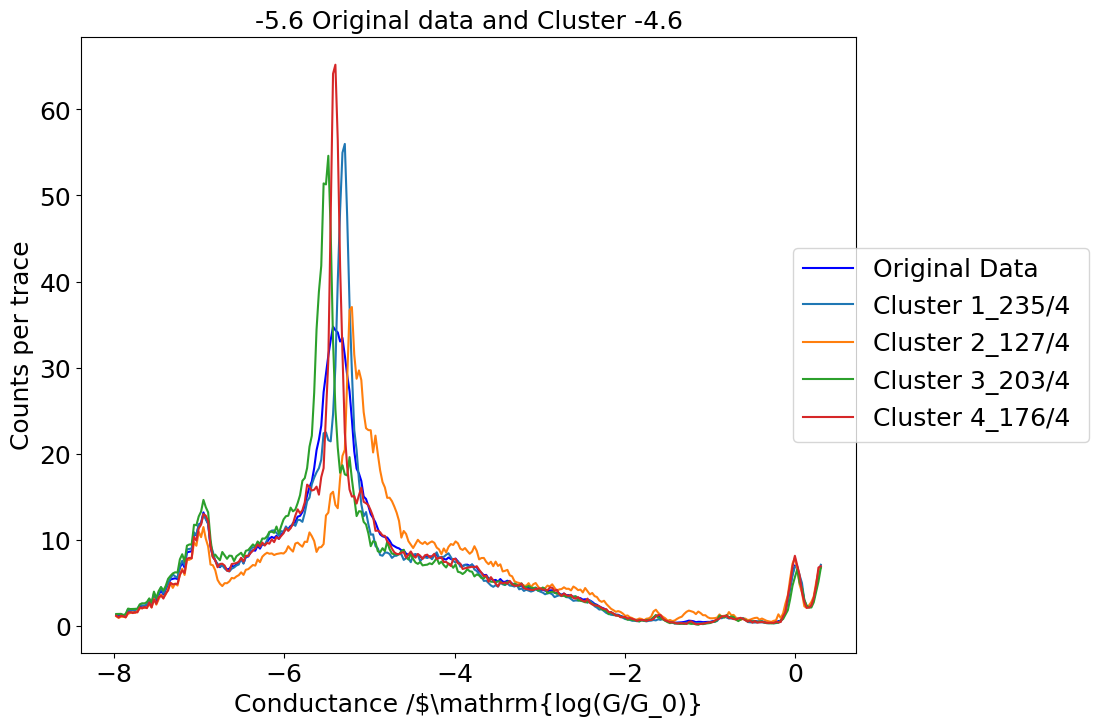

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f6894297ba0>
Traceback (most recent call last):
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 's

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f6894297ba0>
Traceback (most recent call last):
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 's

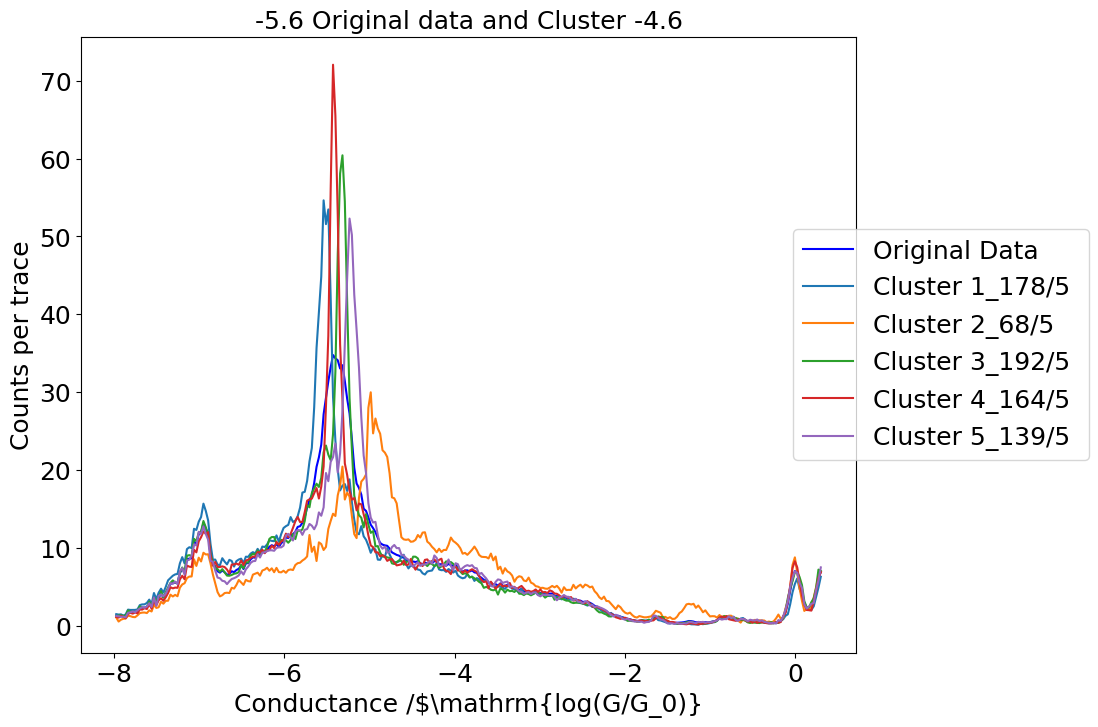

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f68941ef880>
Traceback (most recent call last):
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 's

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f68941ef880>
Traceback (most recent call last):
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/usr/local/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 's

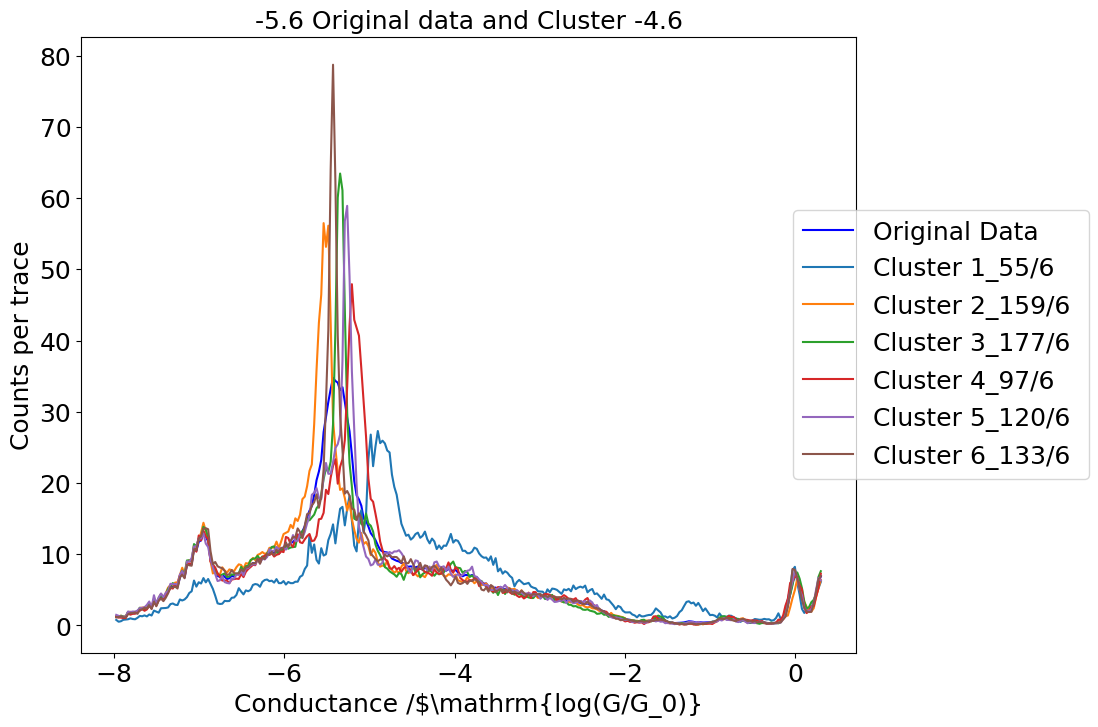

In [15]:
# Clustering the data into 2, 3, ..., n_Clusters clusters sequentially, 
# and the optimal number of clusters will be selected via the CH index subsequently.
n_Clusters = 6
labelsList4allcases = clusteringBtweenSP(-5.6, -4.6, n_Clusters)

## determination of the optimal clusters (CH index)

In [16]:
######  modify based on scikit-learning...
import sklearn.metrics.pairwise as skmp
def calinski_harabasz_score_M(X, labels, metric = 'correlation'):
    ####where a higher Calinski-Harabasz score relates to a model with better defined clusters.
    """Compute the Calinski and Harabasz score.
    It is also known as the Variance Ratio Criterion.
    The score is defined as ratio between the within-cluster dispersion and
    the between-cluster dispersion.
    Read more in the :ref:`User Guide <calinski_harabasz_index>`.
    Parameters
    ----------
    X : array-like, shape (``n_samples``, ``n_features``)
        List of ``n_features``-dimensional data points. Each row corresponds
        to a single data point.
    labels : array-like, shape (``n_samples``,)
        Predicted labels for each sample.
    Returns
    -------
    score : float
        The resulting Calinski-Harabasz score.
    References
    ----------
    .. [1] `T. Calinski and J. Harabasz, 1974. "A dendrite method for cluster
       analysis". Communications in Statistics
       <https://www.tandfonline.com/doi/abs/10.1080/03610927408827101>`_
    """
    
    if metric == 'correlation':
        zerosRows = np.where(np.all(X == 0, axis=1))
        X = np.delete(X,zerosRows, axis=0)
        labels = np.delete(labels, zerosRows)
        
    n_samples, _ = X.shape
    n_labels = len(set(labels))

    extra_disp, intra_disp = 0., 0.
    
    mean = np.mean(X, axis=0)
    
    for k in range(n_labels):
        cluster_k = X[labels == k]  ####cluster 
        mean_k = np.mean(cluster_k, axis=0)
        extra_disp += len(cluster_k) *  (skmp.pairwise_distances(np.array(mean_k, ndmin=2),
                                                                np.array(mean, ndmin=2), 
                                                                metric=metric, n_jobs = -1)**2)[0][0]
        
        intra_disp += np.sum(skmp.pairwise_distances(cluster_k, 
                                                   np.array(mean_k, ndmin=2),
                                                   metric=metric, n_jobs = -1)**2)
    return (1. if intra_disp == 0. else
            extra_disp * (n_samples - n_labels) /
            (intra_disp * (n_labels - 1.)))

In [17]:
def plotCHI(labelsList_7_2, metric='correlation'):
    
    labelsList = labelsList_7_2[0]
    numClusters = len(labelsList)
    calinski_harabasz_Index = np.ndarray(numClusters)
    rangx = range(2,numClusters+2)
    for i in range(numClusters):
        calinski_harabasz_Index[i] = calinski_harabasz_score_M(labelsList_7_2[1],
                                                               labelsList[i], metric=metric)

    y2, = plt.plot(rangx, calinski_harabasz_Index, 'r', label='Calinski-Harabasz')
    plt.legend()
    plt.ylabel('Calinski-Harabasz score ')
    plt.xlabel('Clusters Number')
    plt.title('Calinski-Harabasz Index, higher better' )
    plt.xticks(rangx)
    return calinski_harabasz_Index

array([122.78397207, 197.32771868, 242.42561151, 279.35840806,
       249.85547627])

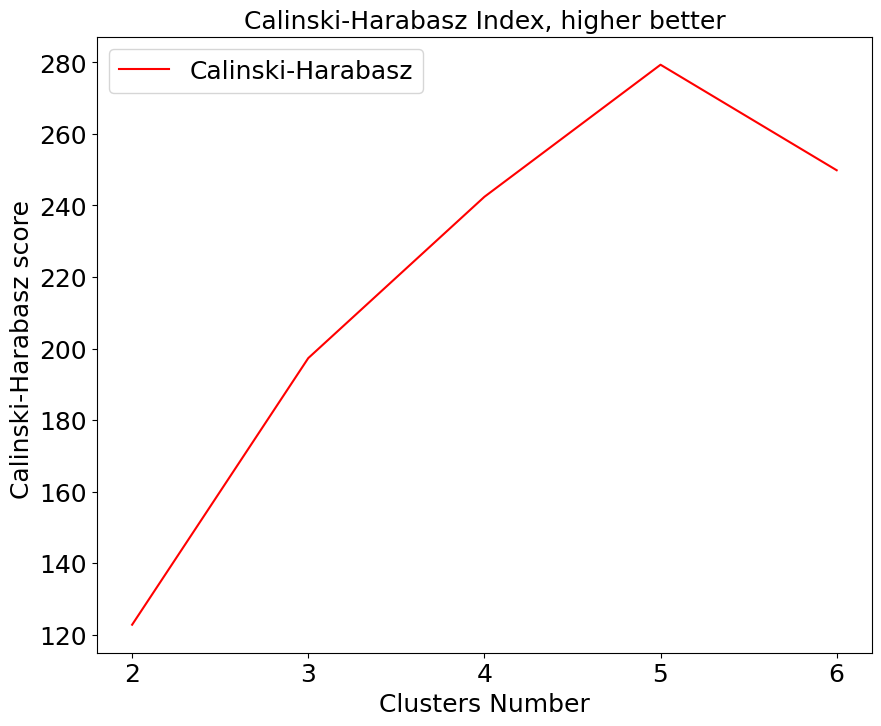

In [18]:
plotCHI(labelsList4allcases)

## Result visualization

5

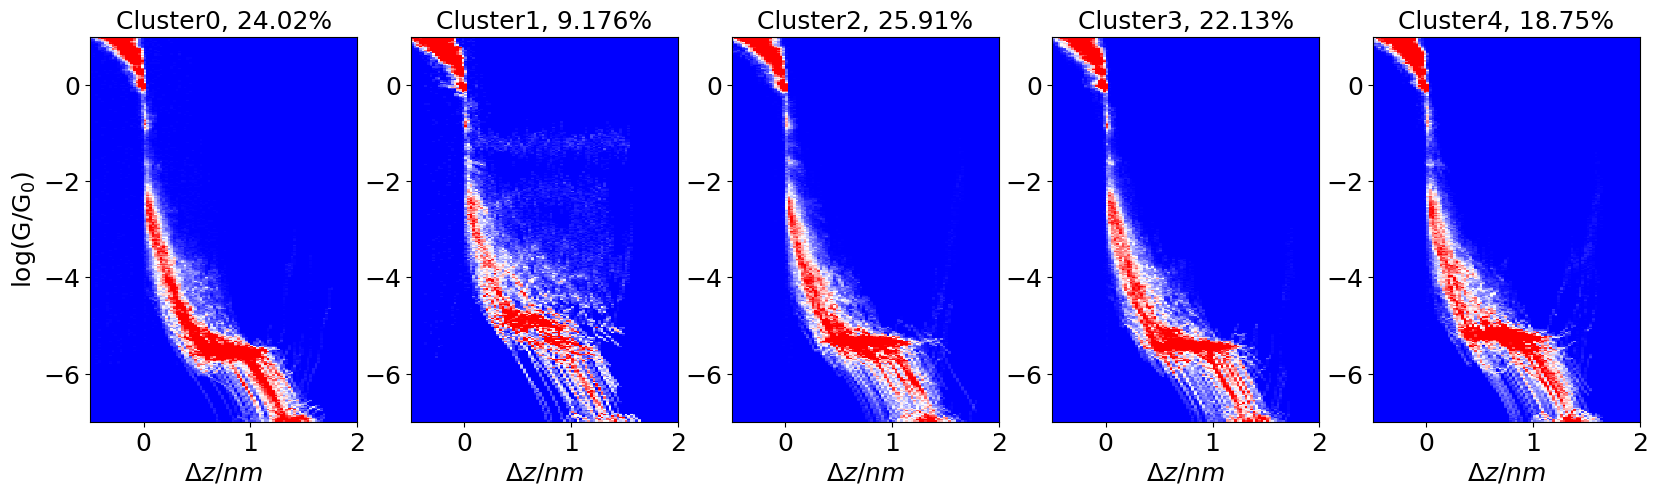

In [23]:
# clustering resluts are stored in labelsList4allcases[0], 
# labelsList4allcases[0][0] means n_Clusters=2, labelsList4allcases[0][1] means n_Clusters=3, ... and so on

# plot 2D hist of each cluster
plot2dCloudofClusters_2(labelsList4allcases[0][3], dataCutFirst4000Curves, 
                        rangeH=((-0.5, 2), (-7, 1)), vmax = .8 )

In [20]:
# # plot 1D hist of each cluster
def plothistofClusters2(label_junc_or_not, dataCut):
    labelsmax = len(set(label_junc_or_not))
    j=0
    plt.figure(figsize=(14, 6), facecolor='white')
    plt.hist(data[:, 1], bins = 500, range=(-7, 0.5),
                                   histtype = 'stepfilled', alpha = 0.2, 
                                   label='Source', density=True,
                                  color='#2F4F4F')
    labelList = [2, 3, 1, 0]
    for j, i in enumerate(labelList):
#         plt.figure(labelsmax, figsize=(7, 5*labelsmax), facecolor='#C0C0C0')

        index_i = np.array(np.where(label_junc_or_not == i)).reshape(-1)

        if index_i.shape[0] < 3:
            continue
        
        ClusterI_Cut = dataCut[index_i]
        
        ClusterI_x, ClusterI = concate_to_one_row(ClusterI_Cut)
        

#         plt.subplot(labelsmax, 1, j+1)
#         j += 1
#         plt.title('ClusterData %s %s' %(i, index_i.shape[0]))
        colors = ['#008B8B', '#228B22', '#48DECC', '#90EE90']
        ClusterI_2dHist = plt.hist(ClusterI, bins = 300, range=(-7, 0.5),
                                   histtype = 'stepfilled', alpha = 0.8, 
                                   label='Cluster:%d'%(i), density=True,
                                  color=colors[j])
        plt.legend(fontsize='x-large', loc='upper center')
#         plt.title('Histogram')
        plt.ylabel('Counts')
        plt.xlabel('$log(G/G_0)$')
        plt.xlim([-7, 1])
        plt.ylim([0, 0.8])
        plt.xticks([i for i in range(-6, 2)])
        plt.grid()

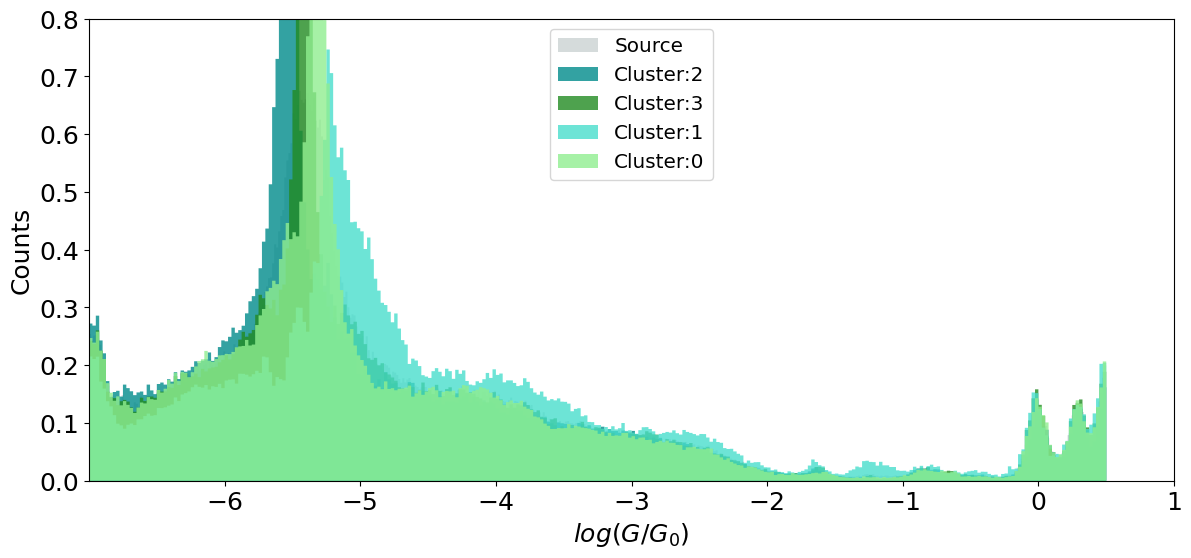

In [21]:
# Display overlaid
plothistofClusters2(labelsList4allcases[0][2], dataCutFirst4000Curves)

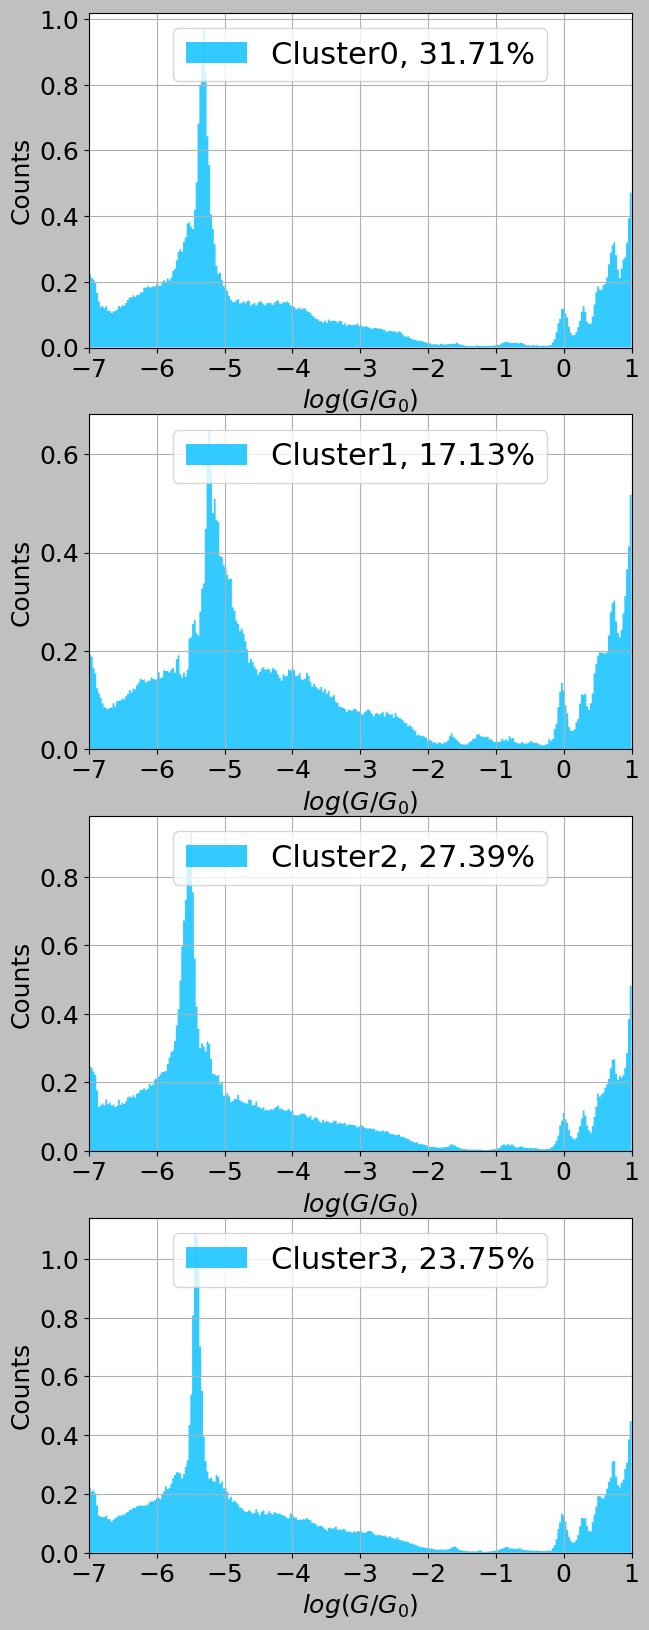

In [22]:
# display independently

plothistofClusters(labelsList4allcases[0][2], dataCutFirst4000Curves)